# Chapter 1

| Module                        | Purpose                                                |
| ----------------------------- | ------------------------------------------------------ |
| `torch`                       | Tensors and tensor operations                          |
| `torch.autograd`              | Automatically computes gradients for backpropagation   |
| `torch.nn`                    | Neural network layers, activations, and loss functions |
| `torch.utils.data.Dataset`    | Converts raw data into tensors                         |
| `torch.utils.data.DataLoader` | Loads, batches, shuffles, and parallelizes data        |
| `torch.optim`                 | Updates model parameters using gradients               |
| `torch.distributed`           | Training across multiple GPUs or machines              |
| `TorchScript` / `ONNX`        | Export trained models for deployment                   |


In [1]:
import torch

In [2]:
torch.cuda.is_available()

False

# Chapter 2

In [3]:
#ALEXNET
import torchvision
from torchvision import models

In [4]:
models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [5]:
alexnet = models.AlexNet()

In [6]:
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 136MB/s]


In [7]:
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

## ViT's conv_proj input are  16x16 chopped patches of 224x224 images

## "An Object that contains parameters and know how  to compute a Forward Pass is a MODULE"

In [8]:
from torchvision import transforms


preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

unsqueeze(0)

(3,224,224)

↓

(1,3,224,224)

Reason:
Models expect batches.
Even one image is treated as batch size 1.

Forward Pass

Input

↓

Neural Network

↓

Logits

Softmax

Converts logits

↓

Probabilities

All outputs

0-1

Sum = 1

## Inference Pipeline

Image

↓

Preprocess

↓

Batch

↓

Model

↓

Logits

↓

Softmax

↓

Prediction

## Important concepts
eval()

dropout

BatchNorm

softmax

logits

top-k

## Important recall questions.

Why do we need batch dimension?

Why logits instead of probabilities?

Why eval()?

Why normalize?

Why does softmax work?

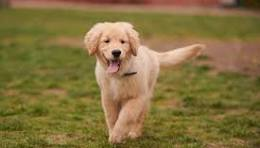

In [12]:
from PIL import Image
img = Image.open('g_retreiver.jpg')
img

In [13]:
img_t = preprocess(img)
img_t

tensor([[[ 0.2111,  0.2282,  0.2453,  ...,  0.7077,  0.7077,  0.7419],
         [ 0.1083,  0.1083,  0.1426,  ...,  0.7077,  0.7077,  0.7248],
         [ 0.0227,  0.0227,  0.0569,  ...,  0.7077,  0.7077,  0.7077],
         ...,
         [ 0.6392,  0.5878,  0.4337,  ..., -0.0287, -0.0458, -0.0116],
         [ 0.6221,  0.6049,  0.5022,  ..., -0.0972, -0.1486, -0.1486],
         [ 0.6049,  0.5878,  0.5536,  ..., -0.1828, -0.2684, -0.2856]],

        [[ 0.0651,  0.0826,  0.1001,  ...,  0.2402,  0.2402,  0.2402],
         [-0.0049, -0.0049,  0.0301,  ...,  0.2577,  0.2577,  0.2577],
         [-0.0574, -0.0574, -0.0399,  ...,  0.2752,  0.2752,  0.2577],
         ...,
         [ 0.2927,  0.2402,  0.0826,  ..., -0.1275, -0.1625, -0.1275],
         [ 0.2927,  0.2577,  0.1702,  ..., -0.1800, -0.2500, -0.2325],
         [ 0.2927,  0.2752,  0.2577,  ..., -0.2500, -0.3550, -0.3725]],

        [[-0.6193, -0.6018, -0.5844,  ..., -0.0441, -0.0441, -0.0267],
         [-0.7238, -0.7238, -0.6890,  ..., -0

In [14]:
import torch
batch_t = torch.unsqueeze(img_t, 0)

In [15]:
vit.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [17]:
out = vit(batch_t)
out

tensor([[-7.7049e-02, -2.3339e-01, -1.8411e-01, -2.0086e-01, -1.9622e-01,
          4.3177e-01,  3.3102e-01,  8.6024e-02, -1.6340e-01, -4.6535e-01,
         -2.3482e-01, -3.1561e-01, -4.6431e-01,  6.9296e-01, -4.6116e-01,
         -2.1259e-01, -4.7166e-01, -3.5055e-01, -5.1480e-02, -9.6946e-02,
          8.9988e-02, -2.0599e-01, -1.0063e-02, -1.3230e-01, -1.6938e-01,
          3.9033e-01,  1.2734e-01,  1.5047e-01, -7.6271e-02,  3.7594e-01,
         -2.3037e-01, -3.2247e-01, -2.8601e-01,  6.4730e-02,  1.6170e-01,
         -1.5591e-01, -3.1016e-01, -8.9162e-01,  4.3712e-01, -1.0077e-01,
          1.8994e-01, -6.7888e-01, -2.2705e-02,  4.3432e-01, -2.5461e-01,
         -5.0577e-02, -4.5788e-01,  1.5775e-01, -3.9701e-01, -2.7103e-02,
         -1.5019e-01,  4.4481e-01, -2.4871e-01, -4.2072e-01, -2.8585e-01,
         -8.4892e-02, -1.2072e-01,  3.1805e-01,  1.4605e-01, -3.8056e-01,
         -5.1921e-01, -3.1826e-01,  4.0569e-01,  2.8824e-02,  4.0077e-02,
          2.4120e-01,  8.9911e-02, -6.